# 1. Setup & Environment
- 공간 데이터 처리 및 포스터용 카토그래피 렌더링 라이브러리 로드
- 한글 폰트(NanumGothic) 및 유니코드 마이너스 부호 환경 구성

In [1]:
# 1. 라이브러리 로드 및 환경 설정
from pathlib import Path
import json
import unicodedata
import warnings

import geopandas as gpd
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

warnings.filterwarnings("ignore")

# 폰트 및 유니코드 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. Configuration & Cartographic Palette Definitions
- 서울시 집계구 폴리곤, 충전소 스냅샷, 아파트 플래그 및 출력 경로 설정
- 학술 포스터 발표용 미니멀리스트 컬러 팔레트 및 서울시 25개 자치구 코드 정의

In [2]:
# 2. 경로 및 지도 스타일 팔레트 정의
BASE_DIR = Path("/mnt/cowork/EV")
BOUNDARY_FP = BASE_DIR / "input/raw/집계구_2016/집계구.shp"
CHARGER_FP = Path(unicodedata.normalize(
    "NFD", str(BASE_DIR / "input/processed/yearly_snapshots_fastonly/metro7_ev_chargers_2024_fastonly.geojson")
))
APT_FP = BASE_DIR / "output/apt_charger_flags/seoul_chargers_2024_apt_v3_final.csv"

DIR_MAPS = BASE_DIR / "output/maps"
DIR_MAPS.mkdir(parents=True, exist_ok=True)
OUT_PNG_MW = DIR_MAPS / "poster_study_area_map_mw.png"

# 서울시 25개 자치구 매핑 딕셔너리
GU_MAP = {
    "11010": "종로구", "11020": "중구", "11030": "용산구", "11040": "성동구", "11050": "광진구",
    "11060": "동대문구", "11070": "중랑구", "11080": "성북구", "11090": "강북구", "11100": "도봉구",
    "11110": "노원구", "11120": "은평구", "11130": "서대문구", "11140": "마포구", "11150": "양천구",
    "11160": "강서구", "11170": "구로구", "11180": "금천구", "11190": "영등포구", "11200": "동작구",
    "11210": "관악구", "11220": "서초구", "11230": "강남구", "11240": "송파구", "11250": "강동구",
}

# 학술 포스터용 카토그래피 팔레트
COLOR_CONFIG = {
    "GU_FILL": "#f7f7f7",      # 자치구 배경 폴리곤 (Light Gray)
    "GU_BORDER": "#636363",    # 자치구 경계선 (Muted Charcoal)
    "PT_COLOR": "#d73027",     # 급속 충전소 포인트 (Crimson Red)
    "TEXT": "#222222",         # 자치구 명칭 텍스트
    "MUTED": "#666666"         # 캡션 및 부제 텍스트
}

print(f">> 출력 대상 맵 파일: {OUT_PNG_MW.name}")

>> 출력 대상 맵 파일: poster_study_area_map_mw.png


# 3. Boundary Data Loader & Topological Sliver Cleaning
- 2016년 집계구 경계를 자치구 단위로 디졸브(Dissolve) 통합
- 미세 틈(Sliver) 및 경계 노이즈 제거를 위한 모폴로지 버퍼 연산(`buffer(15) -> buffer(-15) -> simplify(20)`) 적용

In [3]:
# 3. 자치구 경계 로드 및 위상 노이즈 정제
def load_clean_gu_boundary(boundary_path: Path) -> gpd.GeoDataFrame:
    """집계구 경계를 25개 자치구 단위로 병합하고 미세 위상 틈새를 정제"""
    gdf = gpd.read_file(boundary_path)
    gdf = gdf.set_crs(epsg=5179, allow_override=True)
    gdf["TOT_REG_CD"] = gdf["TOT_REG_CD"].astype(str)
    
    # 서울시 집계구 필터링 및 구 코드 할당
    gdf_seoul = gdf[gdf["TOT_REG_CD"].str.startswith("11")].copy()
    gdf_seoul["gu"] = gdf_seoul["TOT_REG_CD"].str[:5].map(GU_MAP)
    
    # 자치구 단위 디졸브
    gdf_gu = gdf_seoul.dissolve(by="gu").reset_index()
    
    # 집계구 경계 틈새 메우기 및 폴리곤 간소화
    gdf_gu["geometry"] = gdf_gu.geometry.buffer(15).buffer(-15).simplify(20)
    return gdf_gu

gdf_gu = load_clean_gu_boundary(BOUNDARY_FP)
print(f">> 서울시 자치구 경계 정제 완료: 총 {len(gdf_gu)}개 자치구")

>> 서울시 자치구 경계 정제 완료: 총 25개 자치구


# 4. EV Fast Charger Point Loader (Excluding Apartments)
- 2024년 급속충전기 스냅샷 GeoJSON 로드
- 연구 방법론 표준에 맞추어 아파트(v3) 소재 충전소 전면 제외 필터링 및 좌표 변환(EPSG:5179)

In [4]:
# 4. 아파트 제외 급속충전소 위치 데이터 로드
def load_valid_chargers(charger_path: Path, apt_path: Path) -> gpd.GeoDataFrame:
    """아파트 소재를 제외한 서울시 유효 급속충전소 포인트 로드"""
    with open(charger_path, encoding="utf-8") as f:
        data = json.load(f)
        
    df_apt = pd.read_csv(apt_path, dtype={"station_id": str})
    apt_set = set(df_apt[df_apt["is_apt_v3"]]["station_id"])
    
    records = []
    for feat in data["features"]:
        props = feat["properties"]
        if props.get("city") != "서울특별시":
            continue
        sid = str(props.get("station_id"))
        if sid in apt_set:
            continue
            
        lon, lat = feat["geometry"]["coordinates"]
        records.append({
            "station_id": sid,
            "fast_count": int(props.get("fast_count", 0) or 0),
            "geometry": Point(lon, lat)
        })
        
    gdf_pts = gpd.GeoDataFrame(records, geometry="geometry", crs="EPSG:4326")
    return gdf_pts.to_crs(epsg=5179)

gdf_pts = load_valid_chargers(CHARGER_FP, APT_FP)
total_chargers = gdf_pts["fast_count"].sum()
print(f">> 유효 급속충전소: {len(gdf_pts):,}개소 | 총 급속충전기 수: {total_chargers:,}대 (아파트 완전 제외)")

>> 유효 급속충전소: 1,380개소 | 총 급속충전기 수: 3,757대 (아파트 완전 제외)


# 5. Study Area Map Cartographic Rendering & High-Res Export
- 25개 자치구 폴리곤 및 중심점 기반 자치구 명칭 라벨링
- 급속충전소 위치 포인트 중첩, 미니멀리스트 범례 및 논문/포스터 규격(300 DPI) 내보내기

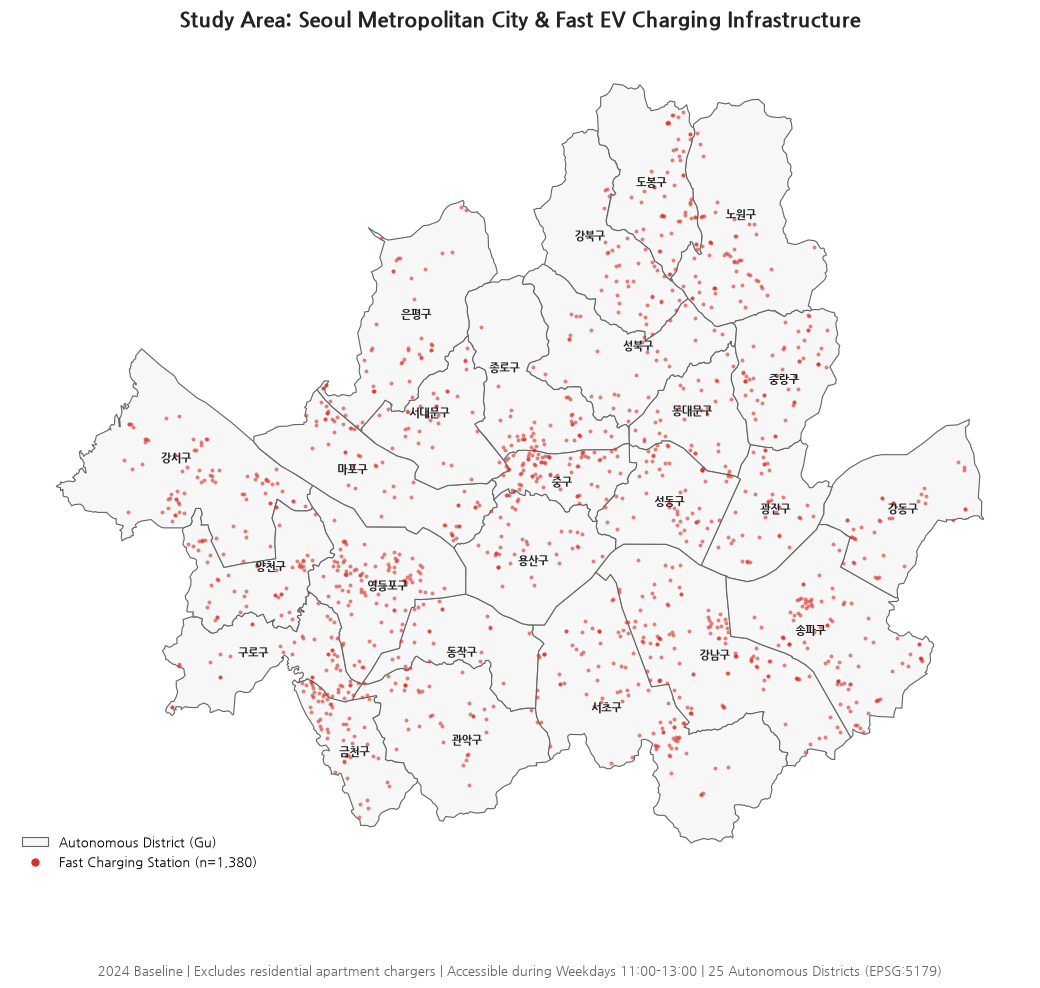

>> 포스터 연구지역 고해상도 지도 저장 완료: /mnt/cowork/EV/output/maps/poster_study_area_map_mw.png


In [7]:
# 5. 연구지역 지도 시각화 및 내보내기
fig, ax = plt.subplots(figsize=(10.5, 11), facecolor="white")

# 1. 자치구 폴리곤 렌더링
gdf_gu.plot(
    ax=ax, 
    color=COLOR_CONFIG["GU_FILL"], 
    edgecolor=COLOR_CONFIG["GU_BORDER"], 
    linewidth=0.8
)

# 2. 급속충전소 포인트 렌더링
gdf_pts.plot(
    ax=ax, 
    color=COLOR_CONFIG["PT_COLOR"], 
    markersize=8, 
    alpha=0.6, 
    linewidth=0
)

# 3. 자치구 명칭 라벨 배치 (Representative Point 기반)
for _, row in gdf_gu.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y, row["gu"], 
        fontsize=8, 
        color=COLOR_CONFIG["TEXT"], 
        ha="center", 
        va="center", 
        fontweight="bold"
    )

ax.set_axis_off()

# 4. 헤더 및 서브타이틀
ax.set_title(
    "Study Area: Seoul Metropolitan City & Fast EV Charging Infrastructure",
    fontsize=15, fontweight="bold", color=COLOR_CONFIG["TEXT"], pad=14
)

# 5. 범례 배치 (좌측 하단)
legend_handles = [
    mpatches.Patch(facecolor=COLOR_CONFIG["GU_FILL"], edgecolor=COLOR_CONFIG["GU_BORDER"], linewidth=0.8, label="Autonomous District (Gu)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_CONFIG["PT_COLOR"], markersize=7, label=f"Fast Charging Station (n={len(gdf_pts):,})"),
]
ax.legend(
    handles=legend_handles, 
    loc="lower left", 
    frameon=False, 
    fontsize=9.5
)

# 6. 하단 메타데이터 캡션 (운영시간 명시)
fig.text(
    0.5, 0.04, 
    f"2024 Baseline | Excludes residential apartment chargers | Accessible during Weekdays 11:00-13:00 | 25 Autonomous Districts (EPSG:5179)",
    ha="center", fontsize=9.5, color=COLOR_CONFIG["MUTED"]
)

# 고해상도(300 DPI) 이미지 내보내기
fig.tight_layout(rect=[0, 0.03, 1, 0.98])
fig.savefig(OUT_PNG_MW, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f">> 포스터 연구지역 고해상도 지도 저장 완료: {OUT_PNG_MW}")

# 6. Output Verification
- 생성된 300 DPI 고해상도 지도 파일의 저장 경로 및 파일 용량(MB) 무결성 확인

In [8]:
# 6. 산출물 파일 상태 확인
if OUT_PNG_MW.exists():
    file_size_mb = OUT_PNG_MW.stat().st_size / (1024 * 1024)
    print("=" * 70)
    print(f"  파일명    : {OUT_PNG_MW.name}")
    print(f"  절대 경로 : {OUT_PNG_MW.resolve()}")
    print(f"  파일 크기 : {file_size_mb:.2f} MB")
    print("  상태      : 정상 저장 완료 (포스터 인쇄 및 발표자료 삽입 가능)")
    print("=" * 70)
else:
    print(f"[!] 파일 저장 실패: {OUT_PNG_MW}")

  파일명    : poster_study_area_map_mw.png
  절대 경로 : /mnt/cowork/EV/output/maps/poster_study_area_map_mw.png
  파일 크기 : 0.67 MB
  상태      : 정상 저장 완료 (포스터 인쇄 및 발표자료 삽입 가능)
